# Red Neuronal Multicapa

En esta guía implementaremos y entrenaremos una red neuronal multicapa

## Importación de librerías

Primero, importamos PyTorch y las herramientas necesarias para manejar datos y visión por computador.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Configuración del dispositivo (usa GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Carga y preparación de datos (FashionMNIST)
Descargamos el dataset y creamos los DataLoaders. FashionMNIST clasifica ropa (camisetas, pantalones, etc.) en 10 categorías.

In [4]:
# Hiperparámetros básicos
BATCH_SIZE = 64

# Transformación: Convertir imagen a tensor y normalizar (opcional pero recomendado)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalización simple media=0.5, std=0.5
])

# Descargar y cargar datos de entrenamiento y prueba
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Mapeo de etiquetas para entender qué estamos clasificando
labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"
}

print(f"Datos de entrenamiento: {len(train_dataset)}")
print(f"Datos de prueba: {len(test_dataset)}")

100%|██████████| 26421880/26421880 [00:04<00:00, 6487215.66it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 173129.53it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 2867244.10it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 9792415.87it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Datos de entrenamiento: 60000
Datos de prueba: 10000


## Definición de la Red Neuronal (MLP)
Aquí definimos una red con dos capas ocultas. A diferencia de la regresión logística (que es lineal), aquí usamos funciones de activación no lineal ReLU para aprender patrones complejos.

In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten() # Convierte la imagen 28x28 en un vector de 784
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),   # Capa de entrada (784) -> Oculta 1 (512)
            nn.ReLU(),               # Función de activación no lineal
            nn.Linear(512, 256),     # Oculta 1 (512) -> Oculta 2 (256)
            nn.ReLU(),
            nn.Linear(256, 10)       # Oculta 2 (256) -> Salida (10 clases)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


## Función de Pérdida y Optimizador
Usamos `CrossEntropyLoss` (estándar para clasificación multiclase) y el optimizador `Adam` (suele converger más rápido que SGD).

In [6]:
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Ciclo de Entrenamiento
Definimos la función que entrenará la red pasando los datos varias veces (epochs).

In [7]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train() # Pone el modelo en modo entrenamiento

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Calcular predicción y pérdida
        pred = model(X)
        loss = loss_fn(pred, y)

        # 2. Backpropagation
        optimizer.zero_grad() # Reiniciar gradientes
        loss.backward()       # Calcular gradientes
        optimizer.step()      # Actualizar pesos

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

## Ciclo de Prueba
Evaluamos qué tan bien generaliza el modelo con datos que nunca ha visto.

In [8]:
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() # Pone el modelo en modo evaluación
    test_loss, correct = 0, 0

    with torch.no_grad(): # No necesitamos calcular gradientes para test
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

## Ejecución
Corremos el entrenamiento por 5 épocas. Deberías ver cómo la precisión (Accuracy) aumenta rápidamente.

In [9]:
EPOCHS = 5

for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, criterion, optimizer)
    test_loop(test_loader, model, criterion)
print("¡Entrenamiento finalizado!")

Epoch 1
-------------------------------
loss: 2.292332  [    0/60000]
loss: 0.565973  [ 6400/60000]
loss: 0.352127  [12800/60000]
loss: 0.616907  [19200/60000]
loss: 0.358838  [25600/60000]
loss: 0.377850  [32000/60000]
loss: 0.415321  [38400/60000]
loss: 0.338783  [44800/60000]
loss: 0.388216  [51200/60000]
loss: 0.270640  [57600/60000]
Test Error: 
 Accuracy: 83.1%, Avg loss: 0.453838 

Epoch 2
-------------------------------
loss: 0.296974  [    0/60000]
loss: 0.426983  [ 6400/60000]
loss: 0.461012  [12800/60000]
loss: 0.365406  [19200/60000]
loss: 0.189409  [25600/60000]
loss: 0.285811  [32000/60000]
loss: 0.317510  [38400/60000]
loss: 0.241299  [44800/60000]
loss: 0.332169  [51200/60000]
loss: 0.239803  [57600/60000]
Test Error: 
 Accuracy: 85.7%, Avg loss: 0.387097 

Epoch 3
-------------------------------
loss: 0.344408  [    0/60000]
loss: 0.258376  [ 6400/60000]
loss: 0.476179  [12800/60000]
loss: 0.247518  [19200/60000]
loss: 0.458188  [25600/60000]
loss: 0.323635  [32000/600

## Visualización de predicciones (Opcional)
Veamos algunas predicciones visuales.

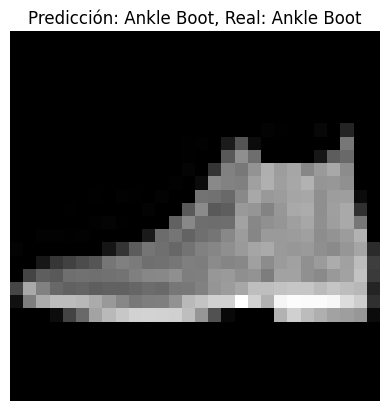

In [10]:
model.eval()
x, y = test_dataset[0][0], test_dataset[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x.unsqueeze(0))
    predicted, actual = labels_map[pred[0].argmax(0).item()], labels_map[y]

    plt.imshow(x.cpu().squeeze(), cmap="gray")
    plt.title(f'Predicción: {predicted}, Real: {actual}')
    plt.axis("off")
    plt.show()

## Conclusiones

Este notebook introduce los siguientes conceptos clave:

1. Capas Ocultas: Permiten aprender características no lineales (bordes, formas).

2. Funciones de Activación (ReLU): Sin ellas, muchas capas serían matemáticamente equivalentes a una sola capa lineal.

3. Flatten: Necesario para pasar de una matriz de imagen 2D a un vector plano que la red densa (Linear) pueda procesar.